# 2.8. Put together ablation montage plots

In [1]:
suppressWarnings(suppressPackageStartupMessages({
    library(jsonlite)
    library(stringr)
    library(dplyr)
    library(purrr)
    library(ggplot2)
    library(cowplot)
    library(magick)
    library(glue)
    library(grid)
}))

## Helper 

In [2]:
read_example_dir <- function(example_dir, density_label, max_degraded = 3) {
  meta_path <- file.path(example_dir, "metadata.json")
  meta <- jsonlite::fromJSON(meta_path, simplifyVector = FALSE)

  param_swept <- meta$param_swept
  ablation_type <- meta$ablation_type

  img_tbl <- tibble(
    path = list.files(example_dir, pattern = "\\.png$", full.names = TRUE),
    file = basename(path),
    stem = tools::file_path_sans_ext(file)
  ) %>%
    mutate(
      parsed_param = str_match(stem, "^(.+)=(.+)$")[, 2],
      level_raw    = str_match(stem, "^(.+)=(.+)$")[, 3],
      is_original  = level_raw == "original",
      level_num    = suppressWarnings(as.numeric(level_raw))
    ) %>%
    filter(parsed_param == param_swept) %>%
    arrange(!is_original, level_num)

  # keep one original
  original_tbl <- img_tbl %>% filter(is_original) %>% slice(1)

  degraded_tbl <- img_tbl %>%
    filter(!is_original) %>%
    arrange(level_num)

  # choose a few representative degraded levels
  if (nrow(degraded_tbl) > max_degraded) {
    keep_idx <- round(seq(1, nrow(degraded_tbl), length.out = max_degraded))
    degraded_tbl <- degraded_tbl[keep_idx, ]
  }

  out <- bind_rows(original_tbl, degraded_tbl) %>%
    mutate(
      density = density_label,
      ablation_type = ablation_type,
      param_swept = param_swept,
      display_label = case_when(
        is_original ~ "Original",
        TRUE ~ paste0(param_swept, " = ", level_raw)
      )
    )

  return(out)
}

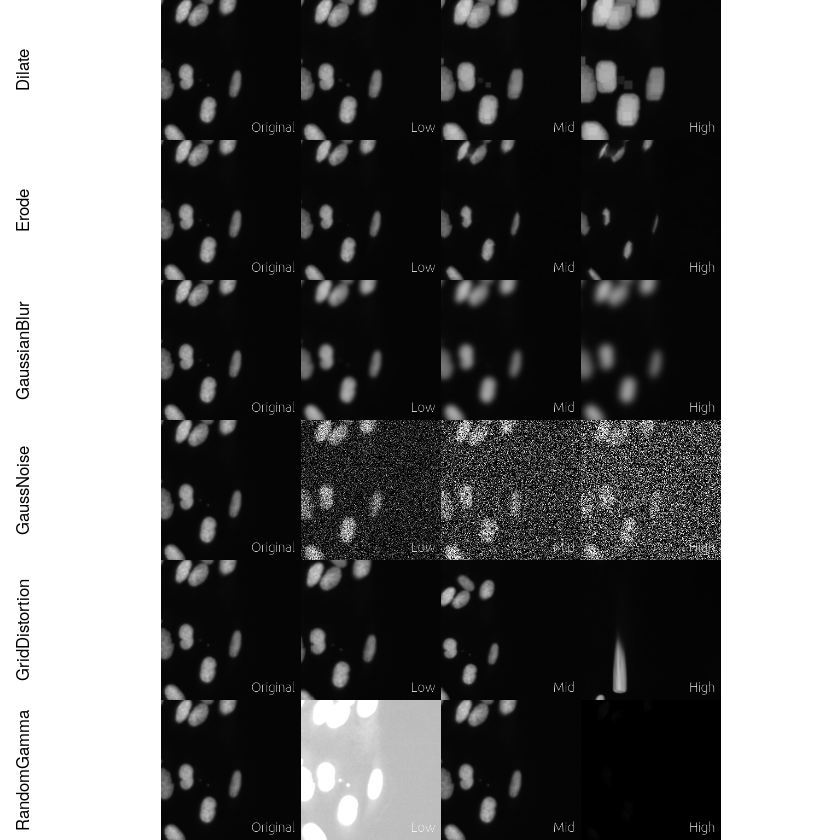

In [3]:
make_row_montage <- function(example_dir, density_label, max_degraded = 6) {
  example_tbl <- read_example_dir(
    example_dir,
    density_label = density_label,
    max_degraded = max_degraded
  )

  if (nrow(example_tbl) == 0) {
    return(NULL)
  }

  example_tbl <- example_tbl %>%
    mutate(
      label = case_when(
        is_original ~ "Original",
        TRUE ~ case_when(
          row_number() == 2 ~ "Low",
          row_number() == 3 ~ "Mid",
          TRUE ~ "High"
        )
      )
    )

  image_list <- map(
    example_tbl$path,
    ~ tryCatch(magick::image_read(.x), error = function(e) NULL)
  ) %>%
    compact()

  if (length(image_list) == 0) {
    return(NULL)
  }

  annotated <- map2(
    image_list,
    example_tbl$label,
    ~ magick::image_annotate(
      .x,
      text = .y,
      color = "white",
      size = 24,
      gravity = "southeast",
      location = "+10+10"
    )
  )

  row_strip <- magick::image_append(magick::image_join(annotated), stack = FALSE)

  list(
    row_strip = row_strip,
    ablation_type = example_tbl$ablation_type[[1]]
  )
}

density_label <- "2000"
combo_dirs <- list.dirs(
  file.path("plots/abl_eg", density_label),
  full.names = TRUE,
  recursive = FALSE
) %>%
  keep(~ str_detect(.x, "^.+/combo_"))

row_info <- map(
  combo_dirs,
  ~ make_row_montage(.x, density_label = density_label, max_degraded = 6)
) %>%
  compact()

if (length(row_info) == 0) {
  stop("No rows produced. Check the combo directories and input images.")
}

row_df <- tibble(
  row_strip = map(row_info, "row_strip"),
  ablation_type = map_chr(row_info, "ablation_type")
) %>%
  arrange(ablation_type)

row_panels <- map(row_df$row_strip, ~ ggdraw() + draw_image(.x, 0, 0, 1, 1))
row_heights <- map_dbl(row_df$row_strip, ~ magick::image_info(.x)$height[1])
row_rel_heights <- row_heights / sum(row_heights)
row_centers <- rev(cumsum(row_rel_heights) - row_rel_heights / 2)

row_panel_montage <- plot_grid(
  plotlist = row_panels,
  ncol = 1,
  align = "v",
  rel_heights = row_rel_heights
)

label_width <- 0.05
panel_montage <- ggdraw() + draw_plot(
  row_panel_montage,
  x = label_width,
  y = 0,
  width = 1 - label_width,
  height = 1
)

for (i in seq_along(row_centers)) {
  panel_montage <- panel_montage + draw_label(
    row_df$ablation_type[i],
    fontface = "plain",
    size = 10,
    angle = 90,
    x = label_width / 2,
    y = row_centers[i],
    hjust = 0.5,
    vjust = 1
  )
}

panel_montage

In [4]:
ggsave(
  filename = "plots/fig_panels/panel_A_montage.png",
  plot = panel_montage,
  width = 5.5,
  height = 8,
  units = "in",
  dpi = 300
 )

ggsave(
  filename = "plots/fig_panels/panel_A_montage.pdf",
  plot = panel_montage,
  width = 5.5,
  height = 8,
  units = "in",
  device = cairo_pdf
)